
     2.	Do strike percentage, walks, or ERA differ systemati
     ally based on the number of rest days/pitch count?

In [162]:
# Question 2: Command and Control Metrics by Rest Days
# Relief Pitchers (2021-2024)

import polars as pl
import numpy as np
import pandas as pd
from plotnine import *
from scipy import stats
import statsmodels.api as sm
import warnings

In [163]:
# Load pitch-level reliever data to calculate command metrics
(reliever_pitches := pl.read_parquet('data/statcast_relievers_final.parquet'))

pitcher_id,date,game_id,velocity,spin_rate,pitch_type_abbr,pitch_type,pitch_result,ab_result,pitch_call,strike_zone,ball_count,strike_count,outs,inning,top_bottom,home_team,away_team,ab_number,pitch_num,batted_ball_type,runner_1b,runner_2b,runner_3b,away_score,home_score,defense_score,offense_score,game_type,batter_side,pitcher_hand,pitcher_days_since_prev_game,pitcher_days_until_next_game,horizontal_movement,vertical_movement,plate_x_position,plate_z_position,year,pitcher_name
i64,datetime[ns],i64,f64,i64,str,str,str,str,str,i64,i64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,f64,f64,f64,f64,i32,str
433589,2021-04-01 00:00:00,634640,85.8,1989,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",41,1,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,-0.58,1.36,-0.88,3.62,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.5,2182,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",12,0,0,1,6,"""Top""","""ATH""","""HOU""",39,1,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,-0.5,1.58,1.87,3.41,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,85.6,2136,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",40,1,null,663656,608324,null,1,0,0,1,"""R""","""L""","""R""",null,3,-0.49,1.4,-1.89,3.07,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,72.4,1772,"""CU""","""Curveball""","""called_strike""",null,"""S""",5,1,0,2,6,"""Top""","""ATH""","""HOU""",41,2,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,1.3,-0.06,0.27,2.94,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.2,2153,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",14,1,0,1,6,"""Top""","""ATH""","""HOU""",39,2,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,-0.64,1.43,1.44,2.54,2021,"""Yusmeiro Petit"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,2024-09-28 00:00:00,745281,94.7,1861,"""SI""","""Sinker""","""foul""",null,"""S""",4,2,2,0,9,"""Top""","""SF""","""STL""",80,5,null,695336,null,null,5,6,6,5,"""R""","""R""","""R""",3,null,-1.5,0.24,-0.79,2.38,2024,"""Spencer Bivens"""
702352,2024-09-28 00:00:00,745281,89.3,1631,"""CH""","""Changeup""","""blocked_ball""",null,"""B""",13,2,2,1,9,"""Top""","""SF""","""STL""",81,5,null,695336,null,null,5,6,6,5,"""R""","""L""","""R""",3,null,-0.89,0.32,-0.2,1.2,2024,"""Spencer Bivens"""
702352,2024-09-28 00:00:00,745281,92.3,2002,"""FC""","""Cutter""","""called_strike""","""strikeout""","""S""",12,2,2,0,9,"""Top""","""SF""","""STL""",80,6,null,695336,null,null,5,6,6,5,"""R""","""R""","""R""",3,null,0.02,0.73,0.67,3.32,2024,"""Spencer Bivens"""


In [164]:
reliever_pitches.select(pl.col('pitch_result').unique()).to_series().to_list()

['hit_into_play',
 'foul',
 'pitchout',
 'missed_bunt',
 'hit_by_pitch',
 'blocked_ball',
 'swinging_strike',
 'foul_tip',
 'bunt_foul_tip',
 'ball',
 'swinging_strike_blocked',
 'automatic_ball',
 'foul_bunt',
 'called_strike',
 'automatic_strike']

In [165]:
# OLD VERSION - See updated versions below using proper strike definitions
# (outing_metrics := (reliever_pitches
#     .with_columns([
#         pl.col('pitch_call').is_in(['S'])
#           .cast(pl.Int32)
#           .alias('is_strike')
#     ])
#     .group_by(['pitcher_id', 'pitcher_name', 'date', 'game_id'])
#     .agg([
#         pl.len().alias('pitch_count'),
#         pl.col('is_strike').sum().alias('strike_count'),
#         (pl.col('is_strike').sum() / pl.len() * 100).alias('strike_pct')
#     ])
#     .sort(['pitcher_id', 'date'])
# ))

## Strike Percentage Calculation - Method 1: Using `pitch_call`

In [166]:
# Strike percentage by outing using pitch_call column
(outing_strike_pct_call := (reliever_pitches
    .with_columns([
        # All strike types from pitch_call
        pl.col('pitch_call').is_in([
            'S'
        ]).cast(pl.Int32).alias('is_strike')
    ])
    .group_by(['pitcher_id', 'pitcher_name', 'date', 'game_id'])
     .agg([
         pl.len().alias('pitch_count'),
         pl.col('is_strike').sum().alias('strike_count'),
         (pl.col('is_strike').sum() / pl.len() * 100).alias('strike_pct_call')
     ])
    .sort(['pitcher_id', 'date'])
))

pitcher_id,pitcher_name,date,game_id,pitch_count,strike_count,strike_pct_call
i64,str,datetime[ns],i64,u32,i32,f64
433589,"""Yusmeiro Petit""",2021-04-01 00:00:00,634640,11,2,18.181818
433589,"""Yusmeiro Petit""",2021-04-04 00:00:00,634651,26,11,42.307692
433589,"""Yusmeiro Petit""",2021-04-06 00:00:00,634628,16,7,43.75
433589,"""Yusmeiro Petit""",2021-04-07 00:00:00,634567,10,4,40.0
433589,"""Yusmeiro Petit""",2021-04-09 00:00:00,634537,8,3,37.5
…,…,…,…,…,…,…
702352,"""Spencer Bivens""",2024-09-19 00:00:00,746985,37,16,43.243243
702352,"""Spencer Bivens""",2024-09-21 00:00:00,746255,28,13,46.428571
702352,"""Spencer Bivens""",2024-09-23 00:00:00,747150,21,11,52.380952


In [167]:
# View results and summary stats for pitch_call method
print("Strike Percentage (pitch_call) Summary:")
print(outing_strike_pct_call.select([
    pl.col('strike_pct_call').min().alias('min'),
    pl.col('strike_pct_call').quantile(0.25).alias('25th'),
    pl.col('strike_pct_call').median().alias('median'),
    pl.col('strike_pct_call').quantile(0.75).alias('75th'),
    pl.col('strike_pct_call').max().alias('max'),
    pl.col('strike_pct_call').mean().alias('mean')
]))

print(f"\nTotal outings: {outing_strike_pct_call.height:,}")
print("\nFirst 10 outings:")
outing_strike_pct_call.head(10)

Strike Percentage (pitch_call) Summary:
shape: (1, 6)
┌─────┬───────────┬───────────┬───────────┬───────┬──────────┐
│ min ┆ 25th      ┆ median    ┆ 75th      ┆ max   ┆ mean     │
│ --- ┆ ---       ┆ ---       ┆ ---       ┆ ---   ┆ ---      │
│ f64 ┆ f64       ┆ f64       ┆ f64       ┆ f64   ┆ f64      │
╞═════╪═══════════╪═══════════╪═══════════╪═══════╪══════════╡
│ 0.0 ┆ 39.130435 ┆ 47.368421 ┆ 55.555556 ┆ 100.0 ┆ 47.35268 │
└─────┴───────────┴───────────┴───────────┴───────┴──────────┘

Total outings: 37,861

First 10 outings:


pitcher_id,pitcher_name,date,game_id,pitch_count,strike_count,strike_pct_call
i64,str,datetime[ns],i64,u32,i32,f64
433589,"""Yusmeiro Petit""",2021-04-01 00:00:00,634640,11,2,18.181818
433589,"""Yusmeiro Petit""",2021-04-04 00:00:00,634651,26,11,42.307692
433589,"""Yusmeiro Petit""",2021-04-06 00:00:00,634628,16,7,43.75
433589,"""Yusmeiro Petit""",2021-04-07 00:00:00,634567,10,4,40.0
433589,"""Yusmeiro Petit""",2021-04-09 00:00:00,634537,8,3,37.5
433589,"""Yusmeiro Petit""",2021-04-12 00:00:00,632231,10,2,20.0
433589,"""Yusmeiro Petit""",2021-04-13 00:00:00,632206,6,3,50.0
433589,"""Yusmeiro Petit""",2021-04-15 00:00:00,634632,13,6,46.153846
433589,"""Yusmeiro Petit""",2021-04-16 00:00:00,634525,19,10,52.631579


## Strike Percentage Calculation - Method 2: Using `pitch_result`

In [168]:
# Check unique pitch_result values
print("Unique pitch_result values:")
print(reliever_pitches.select(pl.col('pitch_result').unique().sort()).to_series().to_list())

Unique pitch_result values:
['automatic_ball', 'automatic_strike', 'ball', 'blocked_ball', 'bunt_foul_tip', 'called_strike', 'foul', 'foul_bunt', 'foul_tip', 'hit_by_pitch', 'hit_into_play', 'missed_bunt', 'pitchout', 'swinging_strike', 'swinging_strike_blocked']


In [169]:
# Strike percentage by outing using pitch_result column
# Note: pitch_result typically uses codes like 'S' = Strike, 'B' = Ball, 'X' = In Play, etc.
(outing_strike_pct_result := (reliever_pitches
.with_columns([
    # Strikes in pitch_result (adjust based on actual values above)
    pl.col('pitch_result').is_in([
        'called_strike',
        'automatic_strike',
        'foul_tip',
        'swinging_strike',
        'missed_bunt',
        'foul',
        'swinging_strike_blocked',
        'bunt_foul_tip',
        'foul_bunt'
    ]).cast(pl.Int32).alias('is_strike')
])
    .group_by(['pitcher_id', 'pitcher_name', 'date', 'game_id'])
    .agg([
        pl.len().alias('pitch_count'),
        pl.col('is_strike').sum().alias('strike_count'),
        (pl.col('is_strike').sum() / pl.len() * 100).alias('strike_pct_result')
    ])
    .sort(['pitcher_id', 'date'])
))

pitcher_id,pitcher_name,date,game_id,pitch_count,strike_count,strike_pct_result
i64,str,datetime[ns],i64,u32,i32,f64
433589,"""Yusmeiro Petit""",2021-04-01 00:00:00,634640,11,2,18.181818
433589,"""Yusmeiro Petit""",2021-04-04 00:00:00,634651,26,11,42.307692
433589,"""Yusmeiro Petit""",2021-04-06 00:00:00,634628,16,7,43.75
433589,"""Yusmeiro Petit""",2021-04-07 00:00:00,634567,10,4,40.0
433589,"""Yusmeiro Petit""",2021-04-09 00:00:00,634537,8,3,37.5
…,…,…,…,…,…,…
702352,"""Spencer Bivens""",2024-09-19 00:00:00,746985,37,16,43.243243
702352,"""Spencer Bivens""",2024-09-21 00:00:00,746255,28,13,46.428571
702352,"""Spencer Bivens""",2024-09-23 00:00:00,747150,21,11,52.380952


In [170]:
# View results and summary stats for pitch_result method
print("Strike Percentage (pitch_result) Summary:")
print(outing_strike_pct_result.select([
    pl.col('strike_pct_result').min().alias('min'),
    pl.col('strike_pct_result').quantile(0.25).alias('25th'),
    pl.col('strike_pct_result').median().alias('median'),
    pl.col('strike_pct_result').quantile(0.75).alias('75th'),
    pl.col('strike_pct_result').max().alias('max'),
    pl.col('strike_pct_result').mean().alias('mean')
]))

print(f"\nTotal outings: {outing_strike_pct_result.height:,}")
print("\nFirst 10 outings:")
outing_strike_pct_result.head(10)

Strike Percentage (pitch_result) Summary:
shape: (1, 6)
┌─────┬───────────┬───────────┬───────────┬───────┬───────────┐
│ min ┆ 25th      ┆ median    ┆ 75th      ┆ max   ┆ mean      │
│ --- ┆ ---       ┆ ---       ┆ ---       ┆ ---   ┆ ---       │
│ f64 ┆ f64       ┆ f64       ┆ f64       ┆ f64   ┆ f64       │
╞═════╪═══════════╪═══════════╪═══════════╪═══════╪═══════════╡
│ 0.0 ┆ 39.130435 ┆ 47.368421 ┆ 55.555556 ┆ 100.0 ┆ 47.352872 │
└─────┴───────────┴───────────┴───────────┴───────┴───────────┘

Total outings: 37,861

First 10 outings:


pitcher_id,pitcher_name,date,game_id,pitch_count,strike_count,strike_pct_result
i64,str,datetime[ns],i64,u32,i32,f64
433589,"""Yusmeiro Petit""",2021-04-01 00:00:00,634640,11,2,18.181818
433589,"""Yusmeiro Petit""",2021-04-04 00:00:00,634651,26,11,42.307692
433589,"""Yusmeiro Petit""",2021-04-06 00:00:00,634628,16,7,43.75
433589,"""Yusmeiro Petit""",2021-04-07 00:00:00,634567,10,4,40.0
433589,"""Yusmeiro Petit""",2021-04-09 00:00:00,634537,8,3,37.5
433589,"""Yusmeiro Petit""",2021-04-12 00:00:00,632231,10,2,20.0
433589,"""Yusmeiro Petit""",2021-04-13 00:00:00,632206,6,3,50.0
433589,"""Yusmeiro Petit""",2021-04-15 00:00:00,634632,13,6,46.153846
433589,"""Yusmeiro Petit""",2021-04-16 00:00:00,634525,19,10,52.631579


## Comparison: pitch_call vs pitch_result

In [171]:
# Join both tables to compare side by side
(comparison := (outing_strike_pct_call
    .select(['pitcher_id', 'pitcher_name', 'date', 'game_id', 'pitch_count', 'strike_pct_call'])
    .join(
        outing_strike_pct_result.select(['pitcher_id', 'date', 'game_id', 'strike_pct_result']),
        on=['pitcher_id', 'date', 'game_id'],
        how='inner'
    )
    .with_columns([
        (pl.col('strike_pct_call') - pl.col('strike_pct_result')).alias('difference')
    ])
))

print("Side-by-side comparison (first 20 outings):")
print(comparison.head(20))

print("\n\nDifference statistics:")
print(comparison.select([
    pl.col('difference').mean().alias('mean_diff'),
    pl.col('difference').abs().mean().alias('mean_abs_diff'),
    pl.col('difference').std().alias('std_diff')
]))

Side-by-side comparison (first 20 outings):
shape: (20, 8)
┌────────────┬────────────┬────────────┬─────────┬────────────┬────────────┬───────────┬───────────┐
│ pitcher_id ┆ pitcher_na ┆ date       ┆ game_id ┆ pitch_coun ┆ strike_pct ┆ strike_pc ┆ differenc │
│ ---        ┆ me         ┆ ---        ┆ ---     ┆ t          ┆ _call      ┆ t_result  ┆ e         │
│ i64        ┆ ---        ┆ datetime[n ┆ i64     ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│            ┆ str        ┆ s]         ┆         ┆ u32        ┆ f64        ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═════════╪════════════╪════════════╪═══════════╪═══════════╡
│ 433589     ┆ Yusmeiro   ┆ 2021-04-01 ┆ 634640  ┆ 11         ┆ 18.181818  ┆ 18.181818 ┆ 0.0       │
│            ┆ Petit      ┆ 00:00:00   ┆         ┆            ┆            ┆           ┆           │
│ 433589     ┆ Yusmeiro   ┆ 2021-04-04 ┆ 634651  ┆ 26         ┆ 42.307692  ┆ 42.307692 ┆ 0.0       │
│            ┆ Petit      ┆ 00:0

## Workload Analysis: Strike Percentage by Rest Days

In [172]:
# Load outing table with rest days and previous pitch count
outing_table = pl.read_parquet('data/outing_table.parquet')

# Join strike percentage with rest days and workload info
(strike_with_rest := (outing_strike_pct_call
    .join(
        outing_table.select(['pitcher_id', 'date', 'game_id', 'rest_days', 'prev_pitch_count']),
        on=['pitcher_id', 'date', 'game_id'],
        how='inner'
    )
    .filter(pl.col('rest_days') <= 10)  # Focus on 0-10 rest days
    .with_columns([
        # Define workload groups based on previous pitch count
        pl.when(pl.col('prev_pitch_count') > 25)
          .then(pl.lit('High Workload (>25 pitches)'))
          .when(pl.col('prev_pitch_count') <= 15)
          .then(pl.lit('Low Workload (≤15 pitches)'))
          .otherwise(pl.lit('Medium Workload (16-25)'))
          .alias('workload_group')
    ])
))

print(f"Total outings with rest days: {strike_with_rest.height:,}")
print("\nWorkload group distribution:")
print(strike_with_rest.group_by('workload_group').agg(pl.len().alias('count')).sort('workload_group'))

Total outings with rest days: 35,737

Workload group distribution:
shape: (3, 2)
┌─────────────────────────────┬───────┐
│ workload_group              ┆ count │
│ ---                         ┆ ---   │
│ str                         ┆ u32   │
╞═════════════════════════════╪═══════╡
│ High Workload (>25 pitches) ┆ 4787  │
│ Low Workload (≤15 pitches)  ┆ 17473 │
│ Medium Workload (16-25)     ┆ 13477 │
└─────────────────────────────┴───────┘


In [173]:
# Aggregate strike percentage by rest days and workload group (High vs Low only)
(strike_by_rest_workload := (strike_with_rest
    .filter(pl.col('workload_group').is_in(['High Workload (>25 pitches)', 'Low Workload (≤15 pitches)']))
    .group_by(['rest_days', 'workload_group'])
    .agg([
        pl.col('strike_pct_call').mean().alias('mean_strike_pct'),
        pl.len().alias('n_outings')
    ])
    .sort(['workload_group', 'rest_days'])
    .to_pandas()
))

print("Strike percentage by rest days and workload:")
print(strike_by_rest_workload)

Strike percentage by rest days and workload:
    rest_days               workload_group  mean_strike_pct  n_outings
0           0  High Workload (>25 pitches)        64.639805          3
1           1  High Workload (>25 pitches)        46.264671        321
2           2  High Workload (>25 pitches)        47.531852       1201
3           3  High Workload (>25 pitches)        46.914317       1389
4           4  High Workload (>25 pitches)        46.949688        847
5           5  High Workload (>25 pitches)        46.227765        481
6           6  High Workload (>25 pitches)        47.148614        278
7           7  High Workload (>25 pitches)        48.199986        142
8           8  High Workload (>25 pitches)        45.379189         69
9           9  High Workload (>25 pitches)        45.967492         35
10         10  High Workload (>25 pitches)        46.647261         21
11          0   Low Workload (≤15 pitches)        44.317304         19
12          1   Low Workload (≤1

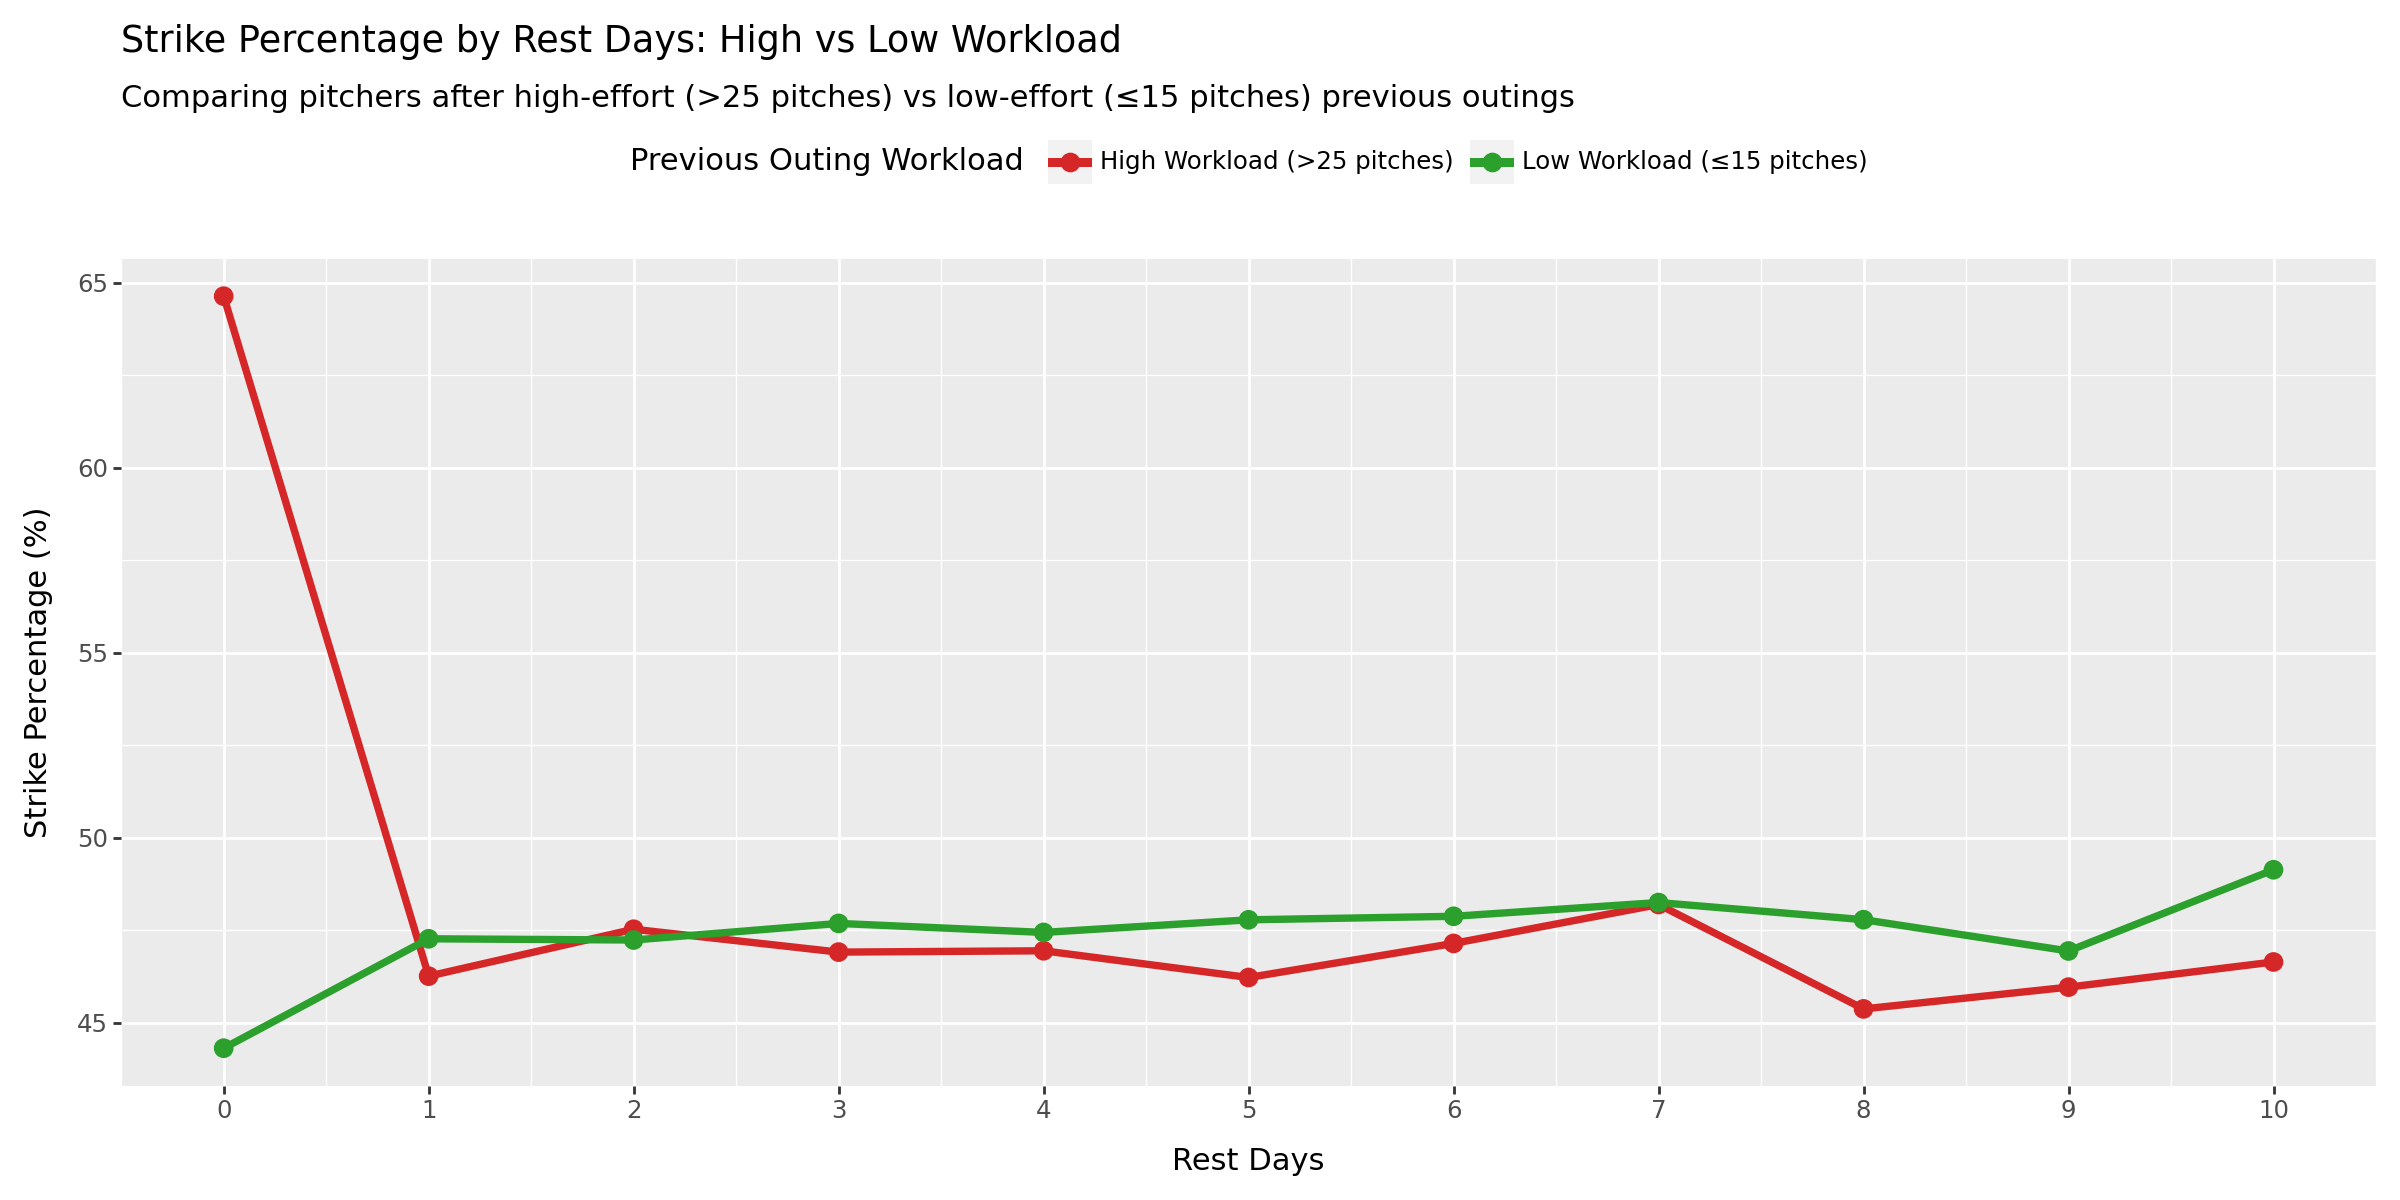

In [174]:
# Line graph: Strike percentage by rest days - High vs Low workload
(ggplot(strike_by_rest_workload, aes(x='rest_days', y='mean_strike_pct', color='workload_group')) +
 geom_line(size=1.5) +
 geom_point(size=3) +
 labs(title='Strike Percentage by Rest Days: High vs Low Workload',
      subtitle='Comparing pitchers after high-effort (>25 pitches) vs low-effort (≤15 pitches) previous outings',
      x='Rest Days',
      y='Strike Percentage (%)',
      color='Previous Outing Workload') +
 scale_x_continuous(breaks=range(0, 11)) +
 scale_color_manual(values=['#d62728', '#2ca02c']) +  # Red for high, green for low
 theme(figure_size=(12, 6),
       legend_position='top'))

## Additional Strike Percentage Visualizations

In [175]:
# 1. Strike % Deviation from Pitcher's Season Average (like velocity analysis in Q1)
# Calculate each pitcher's season average strike percentage
(strike_with_deviation := (strike_with_rest
    .with_columns([
        pl.col('strike_pct_call').mean().over('pitcher_id').alias('season_avg_strike_pct')
    ])
    .with_columns([
        (pl.col('strike_pct_call') - pl.col('season_avg_strike_pct')).alias('strike_pct_deviation')
    ])
))

# Aggregate by rest days
strike_deviation_by_rest = (strike_with_deviation
    .group_by('rest_days')
    .agg([
        pl.col('strike_pct_deviation').mean().alias('mean_deviation'),
        pl.len().alias('n')
    ])
    .sort('rest_days')
    .to_pandas()
)


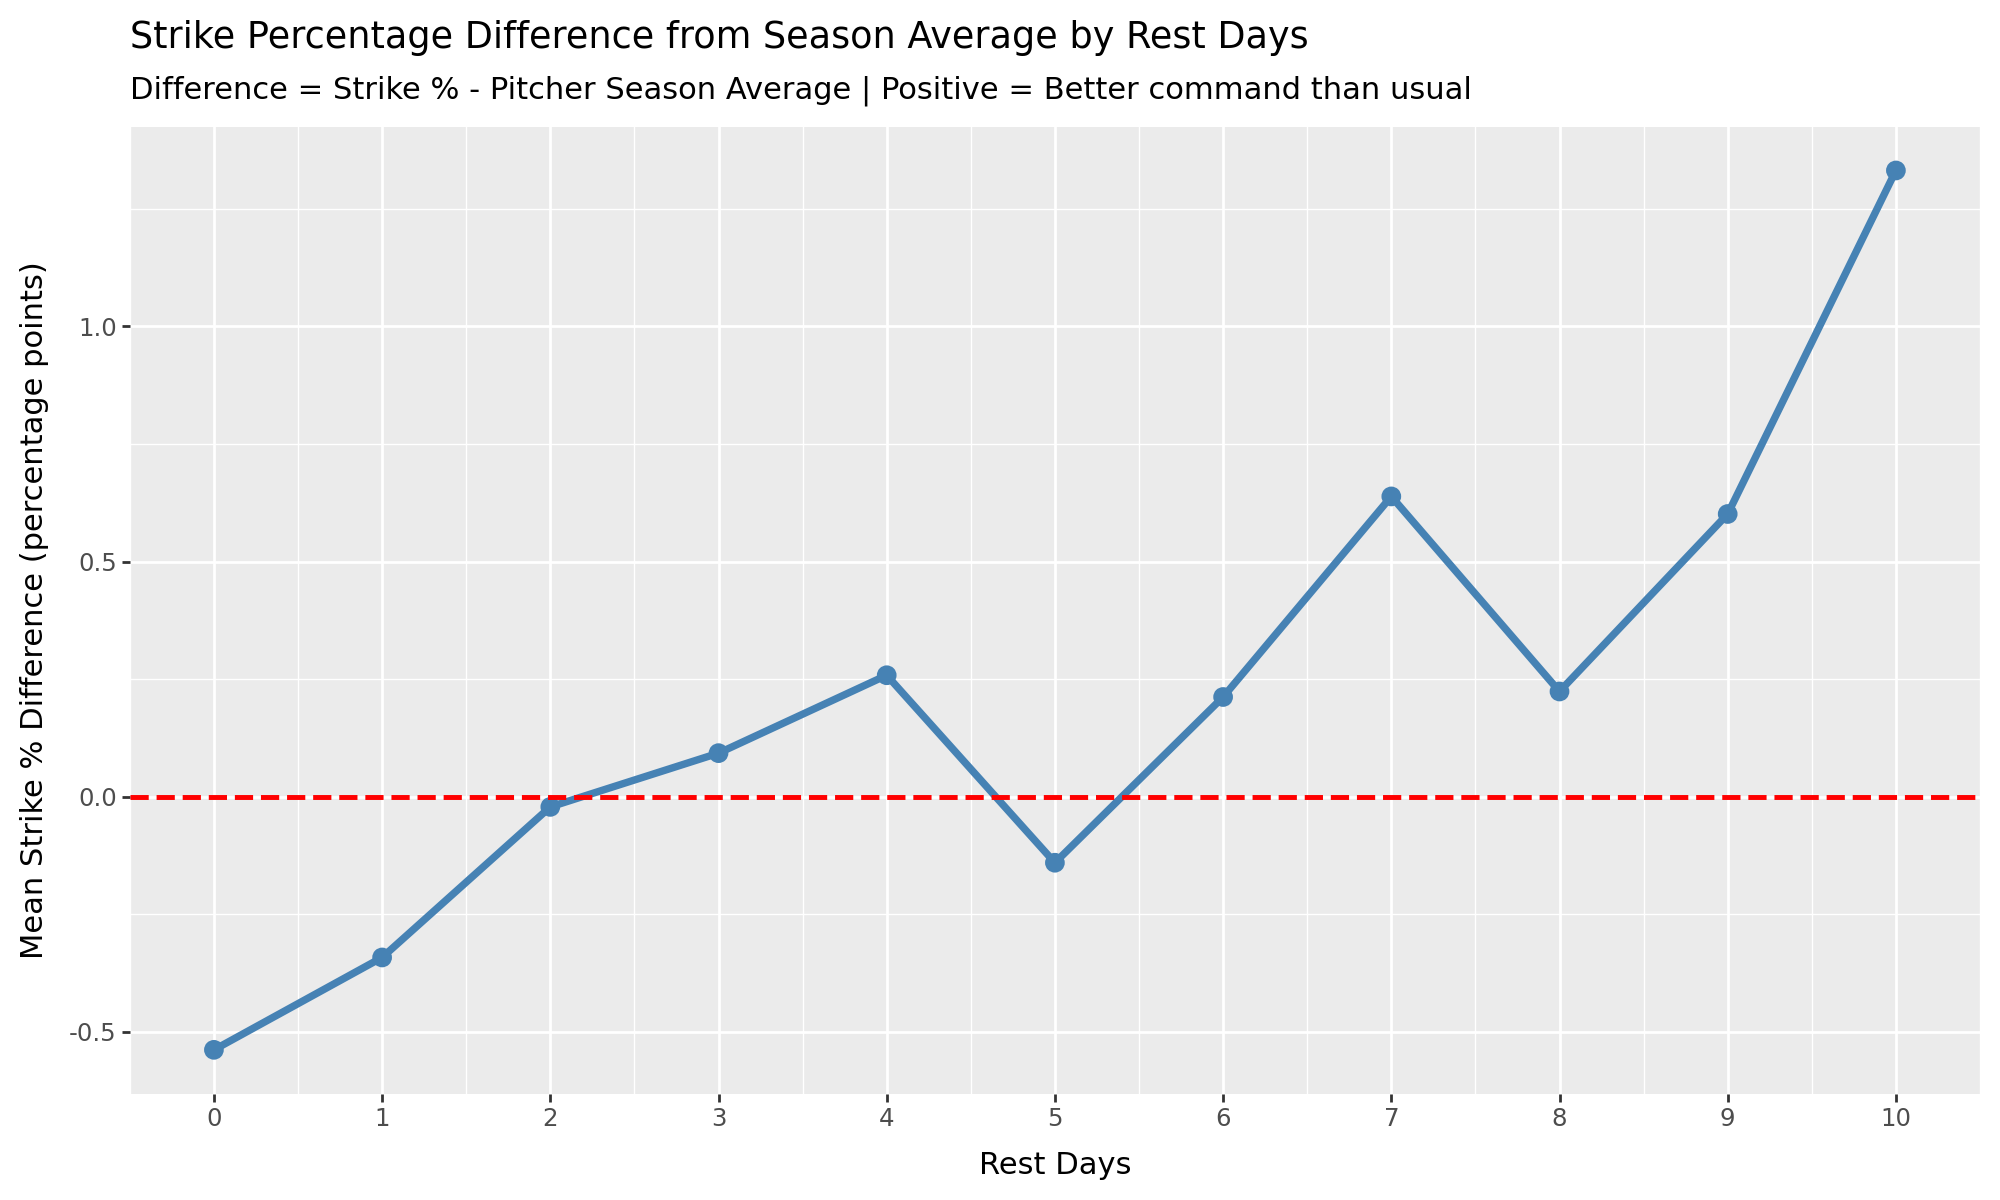

In [176]:
(ggplot(strike_deviation_by_rest, aes(x='rest_days', y='mean_deviation')) +
 geom_line(color='steelblue', size=1.5) +
 geom_point(color='steelblue', size=3) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=1) +
 labs(title='Strike Percentage Difference from Season Average by Rest Days',
      subtitle='Difference = Strike % - Pitcher Season Average | Positive = Better command than usual',
      x='Rest Days',
      y='Mean Strike % Difference (percentage points)') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(10, 6)))

### Statistical Test: Regression Analysis for Strike Percentage

**NOTE**: Requires `strike_with_rest` table to be defined from earlier cells.

In [177]:
# Prepare data for regression: Strike Percentage
# Convert to pandas for statsmodels
strike_reg_data = (strike_with_rest
    .select(['strike_pct_call', 'rest_days', 'prev_pitch_count', 'pitch_count'])
    .to_pandas()
    .dropna()
)

print(f"Sample size for strike % regression: {len(strike_reg_data):,} outings")
print("\nDescriptive statistics:")
display(strike_reg_data.describe())

display(strike_reg_data.head())

Sample size for strike % regression: 35,737 outings

Descriptive statistics:


,strike_pct_call,rest_days,prev_pitch_count,pitch_count
count,35737.000000,35737.000000,35737.000000,35737.000000
mean,47.389371,2.840585,17.061029,17.086745
std,13.581582,1.586711,8.102192,8.106731
min,0.000000,0.000000,1.000000,1.000000
25%,39.285714,2.000000,12.000000,12.000000
50%,47.368421,3.000000,16.000000,16.000000
75%,55.555556,4.000000,21.000000,21.000000
max,100.000000,10.000000,99.000000,99.000000


,strike_pct_call,rest_days,prev_pitch_count,pitch_count
0,43.75,2,26,16
1,40.00,1,16,10
2,37.50,2,10,8
3,20.00,3,8,10
4,50.00,1,10,6


In [178]:
# 2. Strike % by Inning Entered (Early vs Late Relief)
strike_by_inning = (strike_with_rest
    .join(
        outing_table.select(['pitcher_id', 'date', 'game_id', 'inning_entered']),
        on=['pitcher_id', 'date', 'game_id'],
        how='inner'
    )
    .with_columns([
        pl.when(pl.col('inning_entered') >= 7)
          .then(pl.lit('Late (7-9)'))
          .otherwise(pl.lit('Early (1-6)'))
          .alias('inning_group')
    ])
    .group_by(['rest_days', 'inning_group'])
    .agg([
        pl.col('strike_pct_call').mean().alias('mean_strike_pct'),
        pl.len().alias('n')
    ])
    .filter(pl.col('n') >= 30)
    .sort(['inning_group', 'rest_days'])
    .to_pandas()
)

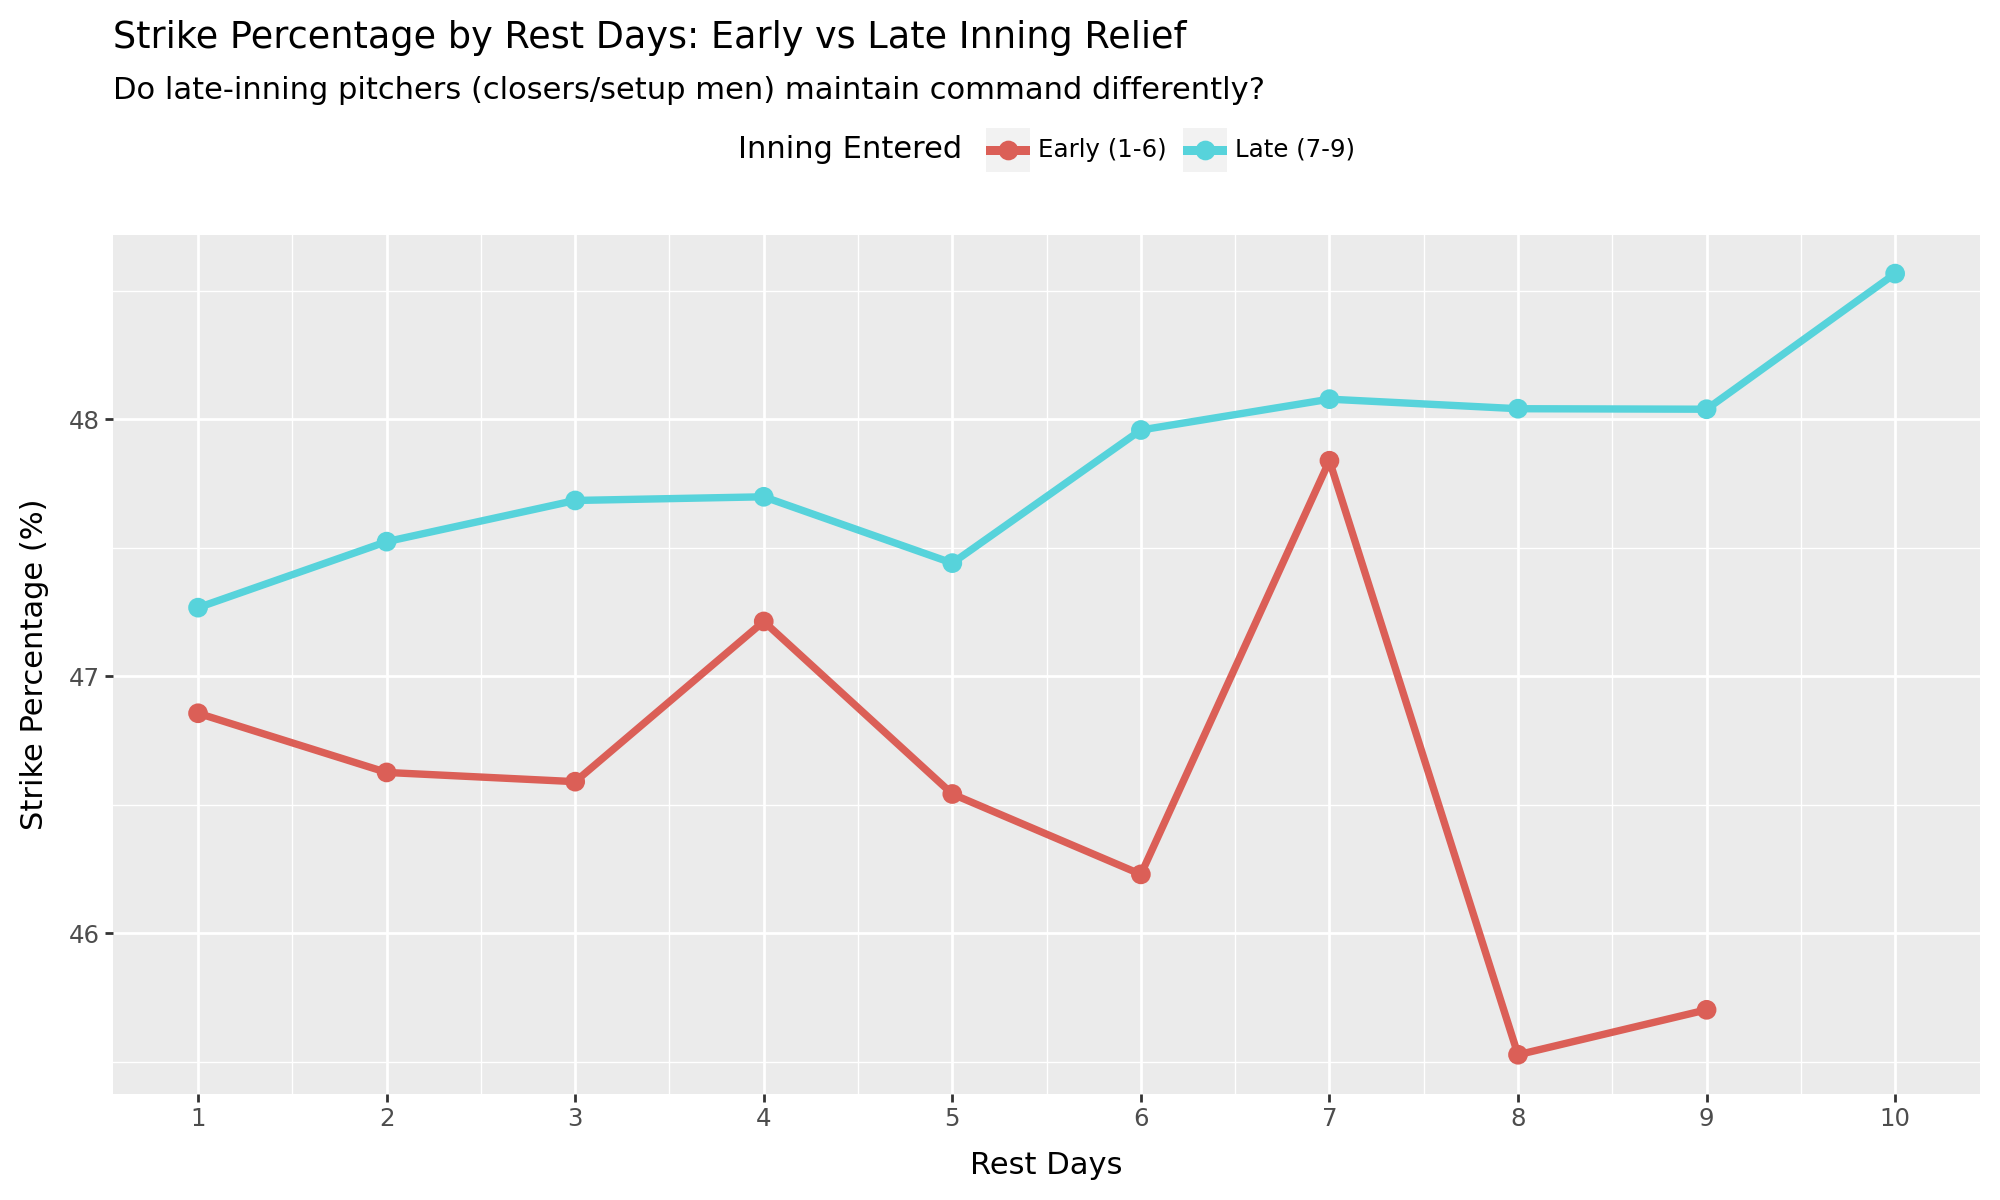

In [179]:
(ggplot(strike_by_inning, aes(x='rest_days', y='mean_strike_pct', color='inning_group')) +
 geom_line(size=1.5) +
 geom_point(size=3) +
 labs(title='Strike Percentage by Rest Days: Early vs Late Inning Relief',
      subtitle='Do late-inning pitchers (closers/setup men) maintain command differently?',
      x='Rest Days',
      y='Strike Percentage (%)',
      color='Inning Entered') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(10, 6),
       legend_position='top'))

In [180]:
# 3. Individual Variability - Spaghetti Plot
# Show how individual pitchers' strike % changes with rest
pitcher_strike_by_rest = (strike_with_deviation
    .group_by(['pitcher_id', 'pitcher_name', 'rest_days'])
    .agg([
        pl.col('strike_pct_deviation').mean().alias('mean_deviation')
    ])
    .sort(['pitcher_id', 'rest_days'])
    .to_pandas()
)

# Overall average
overall_strike_avg = (strike_with_deviation
    .group_by('rest_days')
    .agg([
        pl.col('strike_pct_deviation').mean().alias('mean_deviation')
    ])
    .sort('rest_days')
    .to_pandas()
)

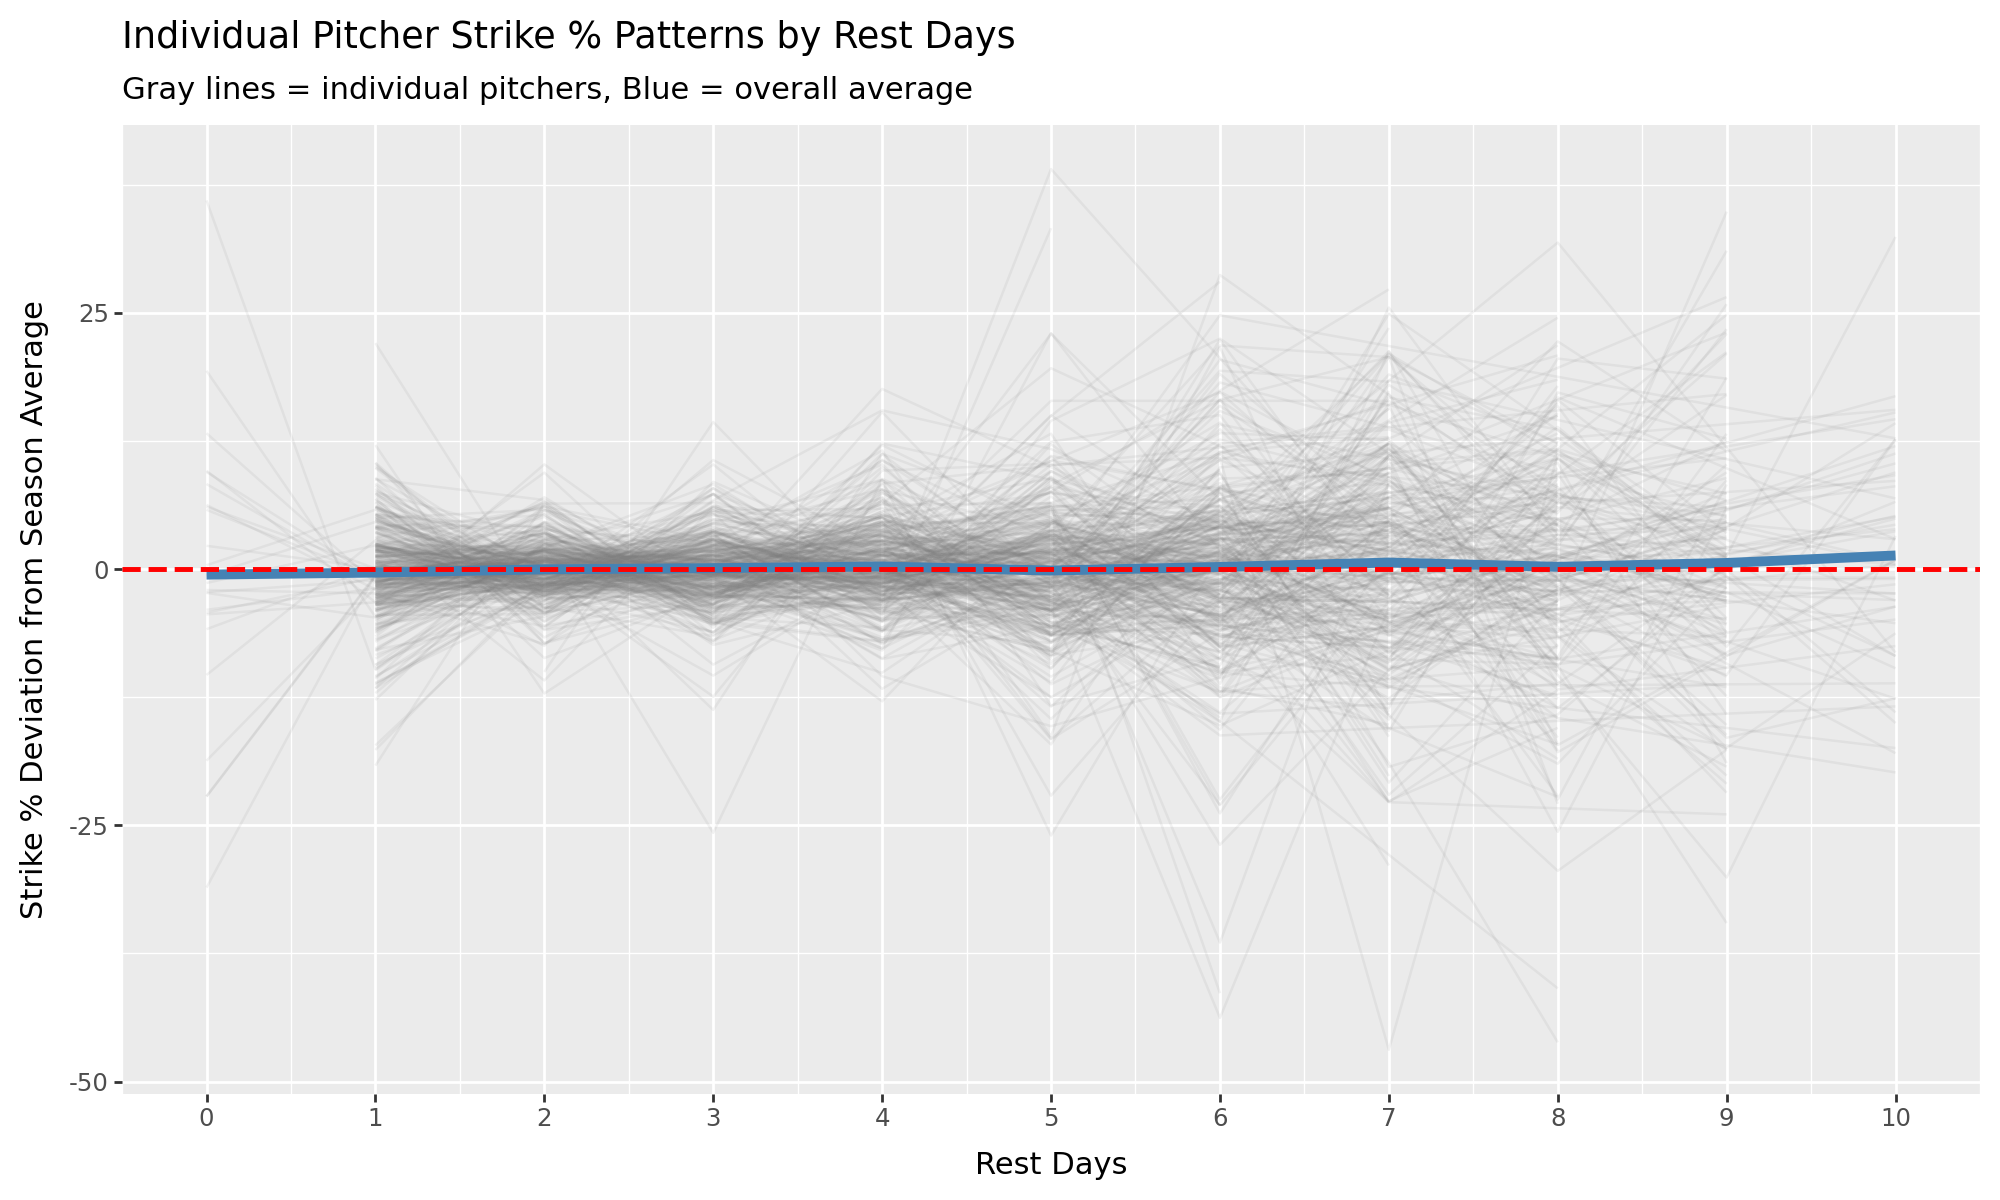

In [181]:
(ggplot() +
 geom_line(data=pitcher_strike_by_rest,
           mapping=aes(x='rest_days', y='mean_deviation', group='pitcher_id'),
           color='gray', alpha=0.1, size=0.5) +
 geom_line(data=overall_strike_avg,
           mapping=aes(x='rest_days', y='mean_deviation'),
           color='steelblue', size=2) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=1) +
 labs(title='Individual Pitcher Strike % Patterns by Rest Days',
      subtitle='Gray lines = individual pitchers, Blue = overall average',
      x='Rest Days',
      y='Strike % Deviation from Season Average') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(10, 6)))

## Walks and WHIP Analysis

In [182]:
# Check what columns are available in outing_table
print("Columns in outing_table:")
print(outing_table.columns)
print("\nFirst few rows:")
outing_table.head(3)

Columns in outing_table:
['pitcher_id', 'game_id', 'date', 'year', 'pitcher_name', 'fb_count', 'mean_fb_velocity', 'max_fb_velocity', 'mean_fb_spin_rate', 'mean_h_movement', 'mean_v_movement', 'inning_entered', 'pitcher_hand', 'score_diff', 'rest_days', 'pitch_count', 'prev_pitch_count', 'season_avg_fb_velo', 'season_avg_fb_spin', 'velo_deviation', 'spin_deviation']

First few rows:


pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124


In [183]:
# Calculate walks per outing from pitch-level data
# Check what ab_result values indicate a walk
print("Unique ab_result values in pitch data:")
print(reliever_pitches.select(pl.col('ab_result').unique().sort()).to_series().to_list()[:30])  # Show first 30

Unique ab_result values in pitch data:
[None, 'catcher_interf', 'double', 'double_play', 'field_error', 'field_out', 'fielders_choice', 'fielders_choice_out', 'force_out', 'grounded_into_double_play', 'hit_by_pitch', 'home_run', 'intent_walk', 'sac_bunt', 'sac_fly', 'sac_fly_double_play', 'single', 'strikeout', 'strikeout_double_play', 'triple', 'triple_play', 'truncated_pa', 'walk']


In [184]:
# Calculate walks per outing
(walks_by_outing := (reliever_pitches
    .group_by(['pitcher_id', 'pitcher_name', 'date', 'game_id'])
    .agg([
        # Count walks (walk, intentional_walk, hit_by_pitch)
        pl.col('ab_result').is_in(['walk', 'intentional_walk', 'hit_by_pitch']).sum().alias('walks'),
        pl.len().alias('pitches')
    ])
    .sort(['pitcher_id', 'date'])
))

# Join with rest days
(walks_with_rest := (walks_by_outing
    .join(
        outing_table.select(['pitcher_id', 'date', 'game_id', 'rest_days', 'prev_pitch_count', 'inning_entered']),
        on=['pitcher_id', 'date', 'game_id'],
        how='inner'
    )
    .filter(pl.col('rest_days') <= 10)
    .with_columns([
        pl.when(pl.col('prev_pitch_count') > 25)
          .then(pl.lit('High Workload (>25 pitches)'))
          .when(pl.col('prev_pitch_count') <= 15)
          .then(pl.lit('Low Workload (≤15 pitches)'))
          .otherwise(pl.lit('Medium Workload (16-25)'))
          .alias('workload_group')
    ])
))

print(f"Total outings with walk data: {walks_with_rest.height:,}")
print("\nWalk summary:")
print(walks_with_rest.select([
    pl.col('walks').mean().alias('mean_walks'),
    pl.col('walks').median().alias('median_walks'),
    pl.col('walks').max().alias('max_walks')
]))

Total outings with walk data: 35,737

Walk summary:
shape: (1, 3)
┌────────────┬──────────────┬───────────┐
│ mean_walks ┆ median_walks ┆ max_walks │
│ ---        ┆ ---          ┆ ---       │
│ f64        ┆ f64          ┆ u32       │
╞════════════╪══════════════╪═══════════╡
│ 0.422923   ┆ 0.0          ┆ 5         │
└────────────┴──────────────┴───────────┘


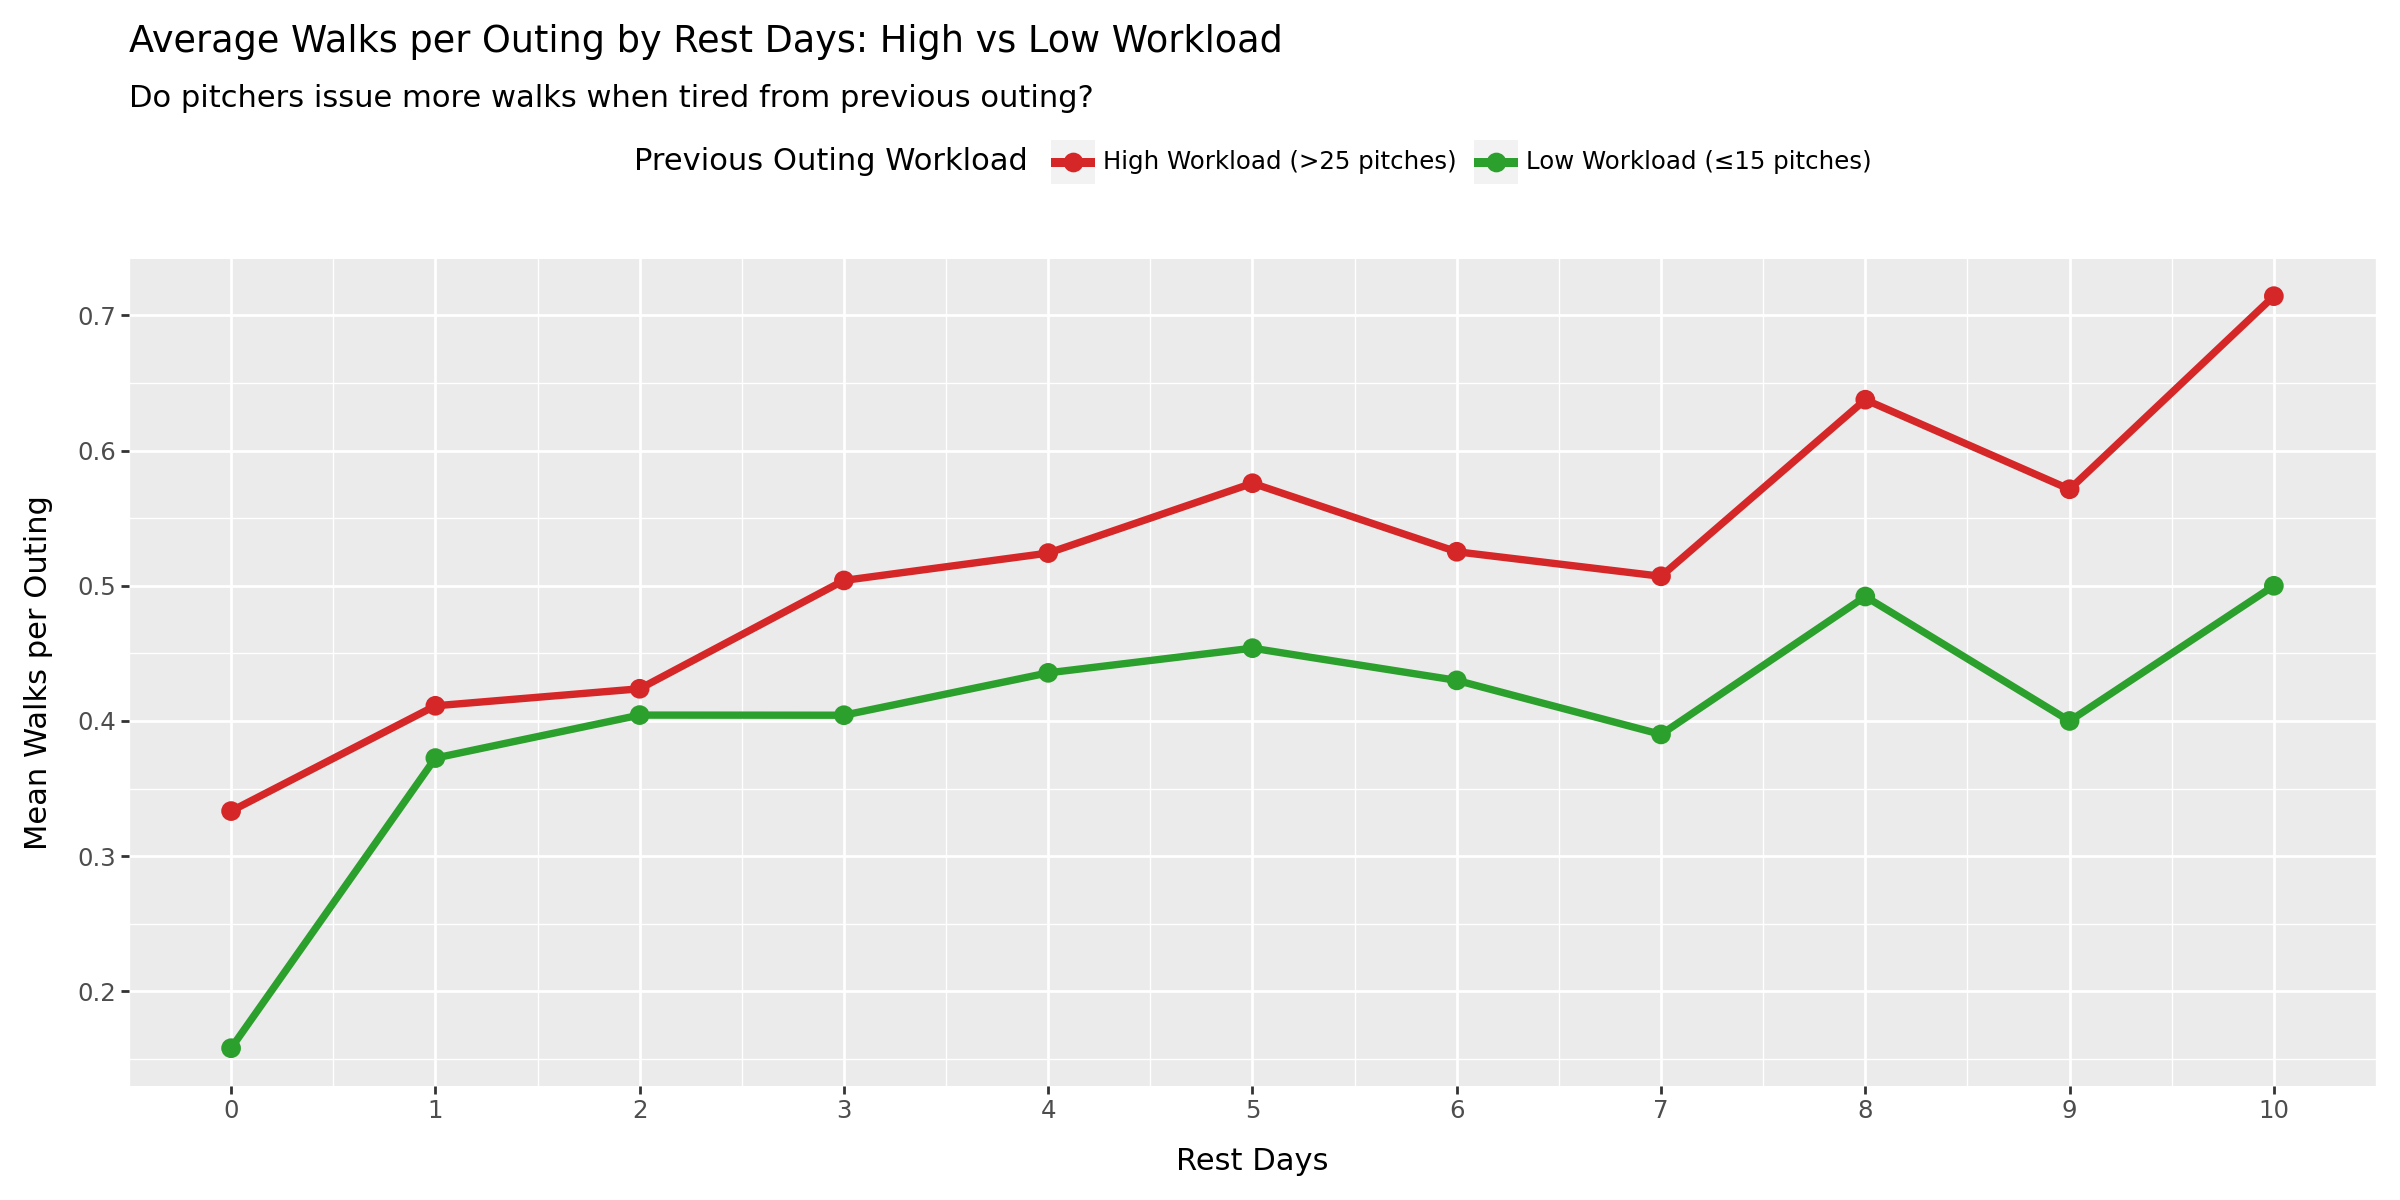

In [185]:
# Walks by rest days and workload
walks_by_rest_workload = (walks_with_rest
    .filter(pl.col('workload_group').is_in(['High Workload (>25 pitches)', 'Low Workload (≤15 pitches)']))
    .group_by(['rest_days', 'workload_group'])
    .agg([
        pl.col('walks').mean().alias('mean_walks'),
        pl.len().alias('n_outings')
    ])
    .sort(['workload_group', 'rest_days'])
    .to_pandas()
)

(ggplot(walks_by_rest_workload, aes(x='rest_days', y='mean_walks', color='workload_group')) +
 geom_line(size=1.5) +
 geom_point(size=3) +
 labs(title='Average Walks per Outing by Rest Days: High vs Low Workload',
      subtitle='Do pitchers issue more walks when tired from previous outing?',
      x='Rest Days',
      y='Mean Walks per Outing',
      color='Previous Outing Workload') +
 scale_x_continuous(breaks=range(0, 11)) +
 scale_color_manual(values=['#d62728', '#2ca02c']) +
 theme(figure_size=(12, 6),
       legend_position='top'))

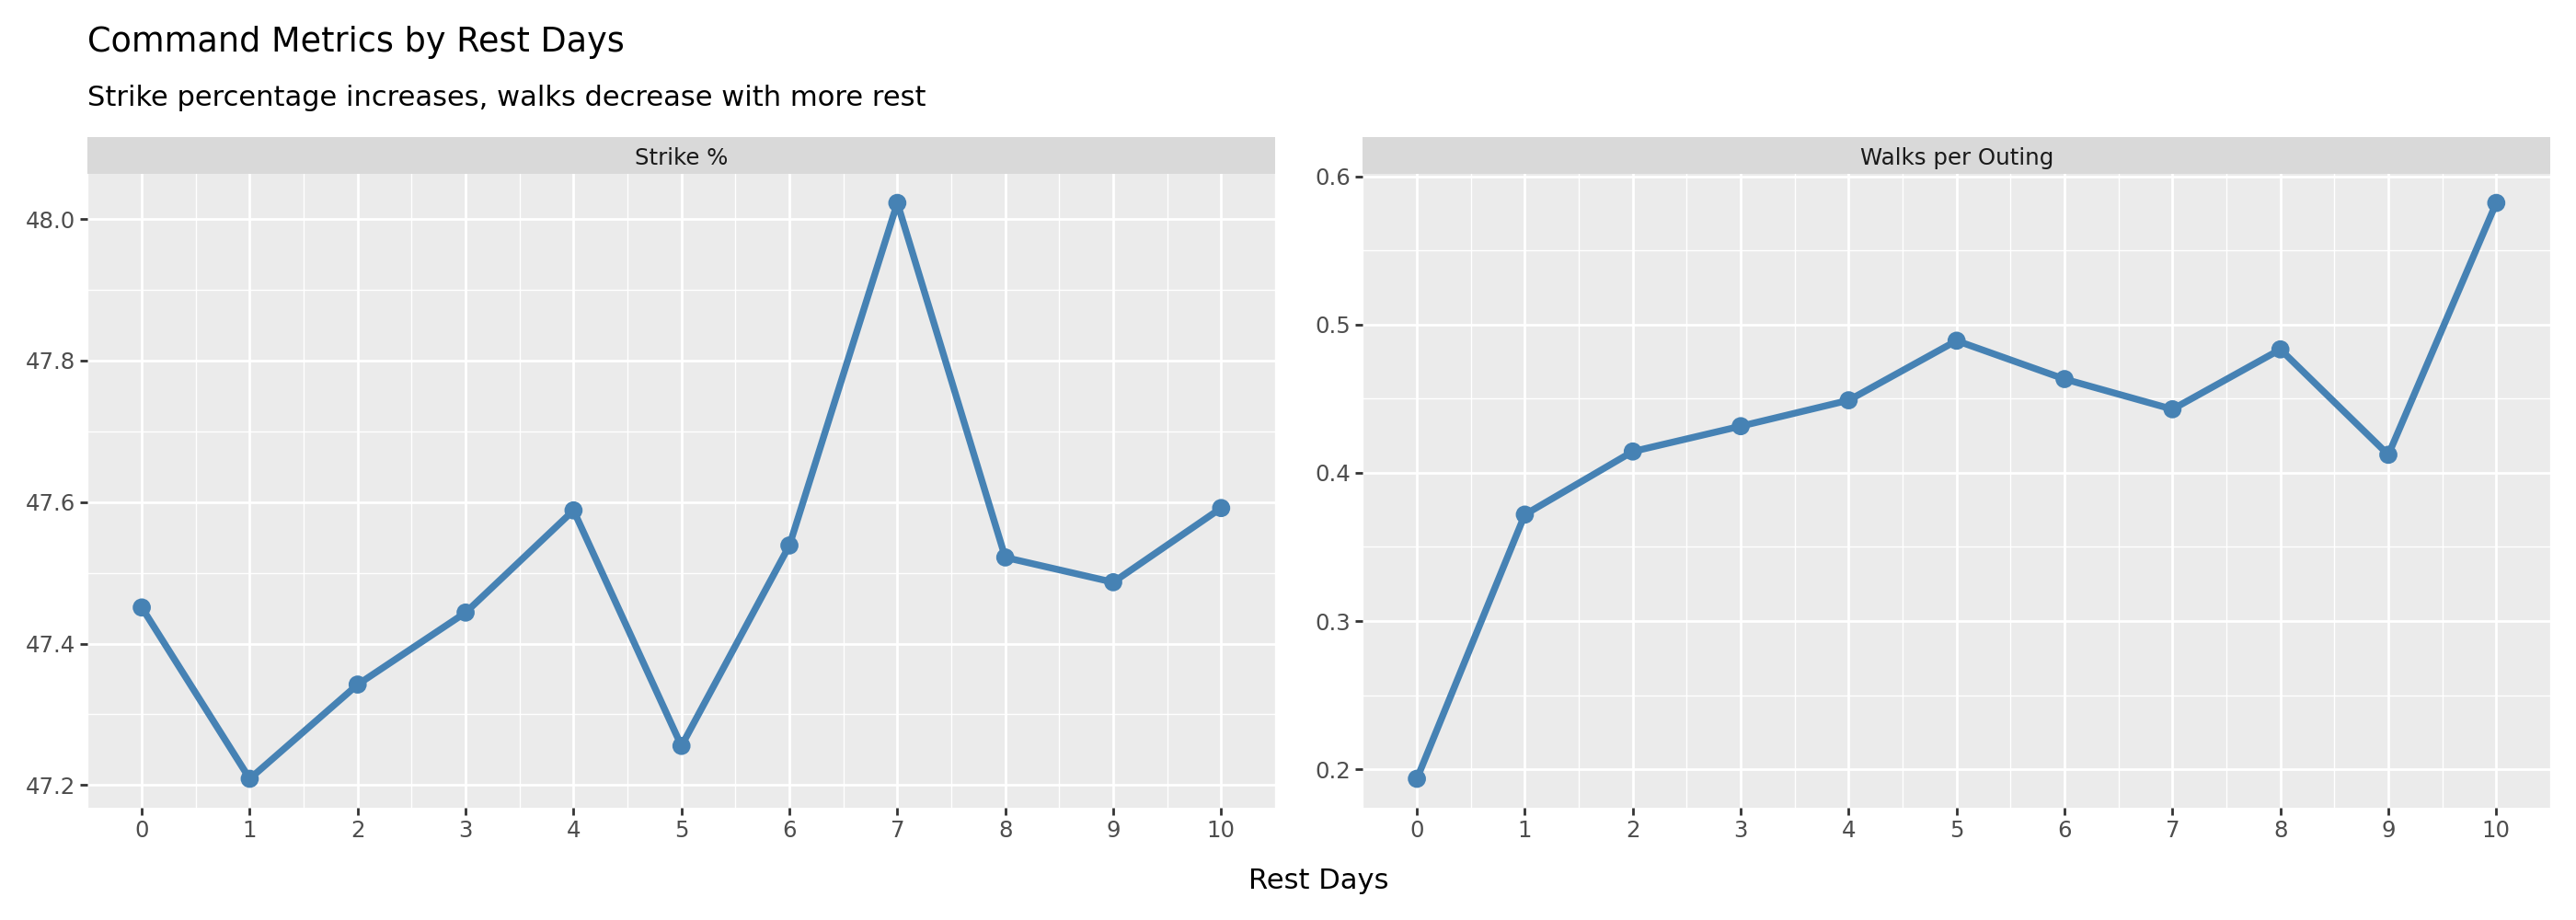

In [186]:
# Combined view: Strike % and Walks by rest days (overall, not by workload)
# Calculate overall averages
overall_strike = (strike_with_rest
    .group_by('rest_days')
    .agg([
        pl.col('strike_pct_call').mean().alias('mean_strike_pct')
    ])
    .sort('rest_days')
    .with_columns([pl.lit('Strike %').alias('metric')])
    .to_pandas()
)

overall_walks = (walks_with_rest
    .group_by('rest_days')
    .agg([
        pl.col('walks').mean().alias('value')
    ])
    .sort('rest_days')
    .with_columns([pl.lit('Walks per Outing').alias('metric')])
    .to_pandas()
)

# Normalize for dual-axis effect (scale walks to similar range as strike %)
overall_walks['normalized_value'] = overall_walks['value'] * 10  # Scale walks up

# Prepare for faceted plot
overall_strike['value'] = overall_strike['mean_strike_pct']
combined_metrics = pd.concat([
    overall_strike[['rest_days', 'value', 'metric']],
    overall_walks[['rest_days', 'value', 'metric']]
])

(ggplot(combined_metrics, aes(x='rest_days', y='value')) +
 geom_line(color='steelblue', size=1.5) +
 geom_point(color='steelblue', size=3) +
 facet_wrap('~metric', scales='free_y', ncol=2) +
 labs(title='Command Metrics by Rest Days',
      subtitle='Strike percentage increases, walks decrease with more rest',
      x='Rest Days',
      y='') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(14, 5)))

## WHIP Analysis (Walks + Hits per Inning Pitched)
WHIP = (Walks + Hits) / Innings Pitched is a key metric for evaluating pitcher effectiveness.

In [187]:
# Calculate WHIP components per outing
# First, check what ab_result values represent hits
print("Checking ab_result values for hits and walks:")
ab_result_counts = (reliever_pitches
    .group_by('ab_result')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
)
print(ab_result_counts)

Checking ab_result values for hits and walks:
shape: (23, 2)
┌───────────────────────┬────────┐
│ ab_result             ┆ count  │
│ ---                   ┆ ---    │
│ str                   ┆ u32    │
╞═══════════════════════╪════════╡
│ null                  ┆ 483799 │
│ field_out             ┆ 62129  │
│ strikeout             ┆ 40968  │
│ single                ┆ 22030  │
│ walk                  ┆ 14009  │
│ …                     ┆ …      │
│ truncated_pa          ┆ 262    │
│ strikeout_double_play ┆ 77     │
│ catcher_interf        ┆ 60     │
│ sac_fly_double_play   ┆ 26     │
│ triple_play           ┆ 6      │
└───────────────────────┴────────┘


In [188]:
# Calculate WHIP per outing
# WHIP = (Walks + Hits) / Innings Pitched
(whip_by_outing := (reliever_pitches
    .group_by(['pitcher_id', 'pitcher_name', 'date', 'game_id'])
    .agg([
        # Count walks (walk, intentional_walk)
        pl.col('ab_result').is_in(['walk', 'intentional_walk']).sum().alias('walks'),
        # Count hits (single, double, triple, home_run)
        pl.col('ab_result').is_in(['single', 'double', 'triple', 'home_run']).sum().alias('hits'),
        # Count outs to calculate innings pitched (3 outs = 1 inning)
        pl.col('outs').max().alias('outs_recorded')
    ])
    .with_columns([
        # Calculate innings pitched (outs / 3)
        (pl.col('outs_recorded') / 3.0).alias('innings_pitched'),
        # Calculate WHIP
        pl.when(pl.col('outs_recorded') > 0)
          .then((pl.col('walks') + pl.col('hits')) / (pl.col('outs_recorded') / 3.0))
          .otherwise(None)
          .alias('whip')
    ])
    .filter(pl.col('innings_pitched') > 0)  # Only include outings with at least 1 out
    .sort(['pitcher_id', 'date'])
))

print(f"Total outings with WHIP data: {whip_by_outing.height:,}")
print("\nWHIP summary:")
print(whip_by_outing.select([
    pl.col('whip').mean().alias('mean_whip'),
    pl.col('whip').median().alias('median_whip'),
    pl.col('whip').quantile(0.25).alias('25th_percentile'),
    pl.col('whip').quantile(0.75).alias('75th_percentile')
]))
print("\nFirst 10 outings:")
whip_by_outing.head(10)

Total outings with WHIP data: 37,247

WHIP summary:
shape: (1, 4)
┌───────────┬─────────────┬─────────────────┬─────────────────┐
│ mean_whip ┆ median_whip ┆ 25th_percentile ┆ 75th_percentile │
│ ---       ┆ ---         ┆ ---             ┆ ---             │
│ f64       ┆ f64         ┆ f64             ┆ f64             │
╞═══════════╪═════════════╪═════════════════╪═════════════════╡
│ 2.062636  ┆ 1.5         ┆ 0.0             ┆ 3.0             │
└───────────┴─────────────┴─────────────────┴─────────────────┘

First 10 outings:


pitcher_id,pitcher_name,date,game_id,walks,hits,outs_recorded,innings_pitched,whip
i64,str,datetime[ns],i64,u32,u32,i64,f64,f64
433589,"""Yusmeiro Petit""",2021-04-01 00:00:00,634640,0,1,2,0.666667,1.5
433589,"""Yusmeiro Petit""",2021-04-04 00:00:00,634651,0,2,2,0.666667,3.0
433589,"""Yusmeiro Petit""",2021-04-06 00:00:00,634628,1,1,2,0.666667,3.0
433589,"""Yusmeiro Petit""",2021-04-07 00:00:00,634567,0,0,2,0.666667,0.0
433589,"""Yusmeiro Petit""",2021-04-09 00:00:00,634537,0,1,2,0.666667,1.5
433589,"""Yusmeiro Petit""",2021-04-12 00:00:00,632231,0,1,2,0.666667,1.5
433589,"""Yusmeiro Petit""",2021-04-13 00:00:00,632206,0,0,2,0.666667,0.0
433589,"""Yusmeiro Petit""",2021-04-15 00:00:00,634632,0,0,2,0.666667,0.0
433589,"""Yusmeiro Petit""",2021-04-16 00:00:00,634525,0,1,2,0.666667,1.5


### Regression Analysis: WHIP

**NOTE**: Requires `whip_with_rest` table to be defined from earlier cells.

In [189]:
# Join WHIP with rest days
(whip_with_rest := (whip_by_outing
    .join(
        outing_table.select(['pitcher_id', 'date', 'game_id', 'rest_days', 'prev_pitch_count']),
        on=['pitcher_id', 'date', 'game_id'],
        how='inner'
    )
    .filter(pl.col('rest_days') <= 10)  # Focus on 0-10 rest days
    .with_columns([
        # Define workload groups based on previous pitch count
        pl.when(pl.col('prev_pitch_count') > 25)
          .then(pl.lit('High Workload (>25 pitches)'))
          .when(pl.col('prev_pitch_count') <= 15)
          .then(pl.lit('Low Workload (≤15 pitches)'))
          .otherwise(pl.lit('Medium Workload (16-25)'))
          .alias('workload_group')
    ])
))

print(f"Total outings with WHIP and rest days: {whip_with_rest.height:,}")

Total outings with WHIP and rest days: 35,155


In [190]:
# WHIP by rest days and workload (High vs Low)
whip_by_rest_workload = (whip_with_rest
    .filter(pl.col('workload_group').is_in(['High Workload (>25 pitches)', 'Low Workload (≤15 pitches)']))
    .group_by(['rest_days', 'workload_group'])
    .agg([
        pl.col('whip').mean().alias('mean_whip'),
        pl.len().alias('n_outings')
    ])
    .filter(pl.col('n_outings') >= 30)  # Filter for reliable sample sizes
    .sort(['workload_group', 'rest_days'])
    .to_pandas()
)

print("WHIP by rest days and workload:")
print(whip_by_rest_workload)

WHIP by rest days and workload:
    rest_days               workload_group  mean_whip  n_outings
0           1  High Workload (>25 pitches)   2.148265        317
1           2  High Workload (>25 pitches)   2.201777       1182
2           3  High Workload (>25 pitches)   2.328717       1372
3           4  High Workload (>25 pitches)   2.486277        838
4           5  High Workload (>25 pitches)   2.625000        476
5           6  High Workload (>25 pitches)   2.794224        277
6           7  High Workload (>25 pitches)   2.489362        141
7           8  High Workload (>25 pitches)   2.867647         68
8           9  High Workload (>25 pitches)   2.614286         35
9           1   Low Workload (≤15 pitches)   1.878944       4089
10          2   Low Workload (≤15 pitches)   1.997918       5284
11          3   Low Workload (≤15 pitches)   2.037325       3791
12          4   Low Workload (≤15 pitches)   2.114138       2037
13          5   Low Workload (≤15 pitches)   2.039062     

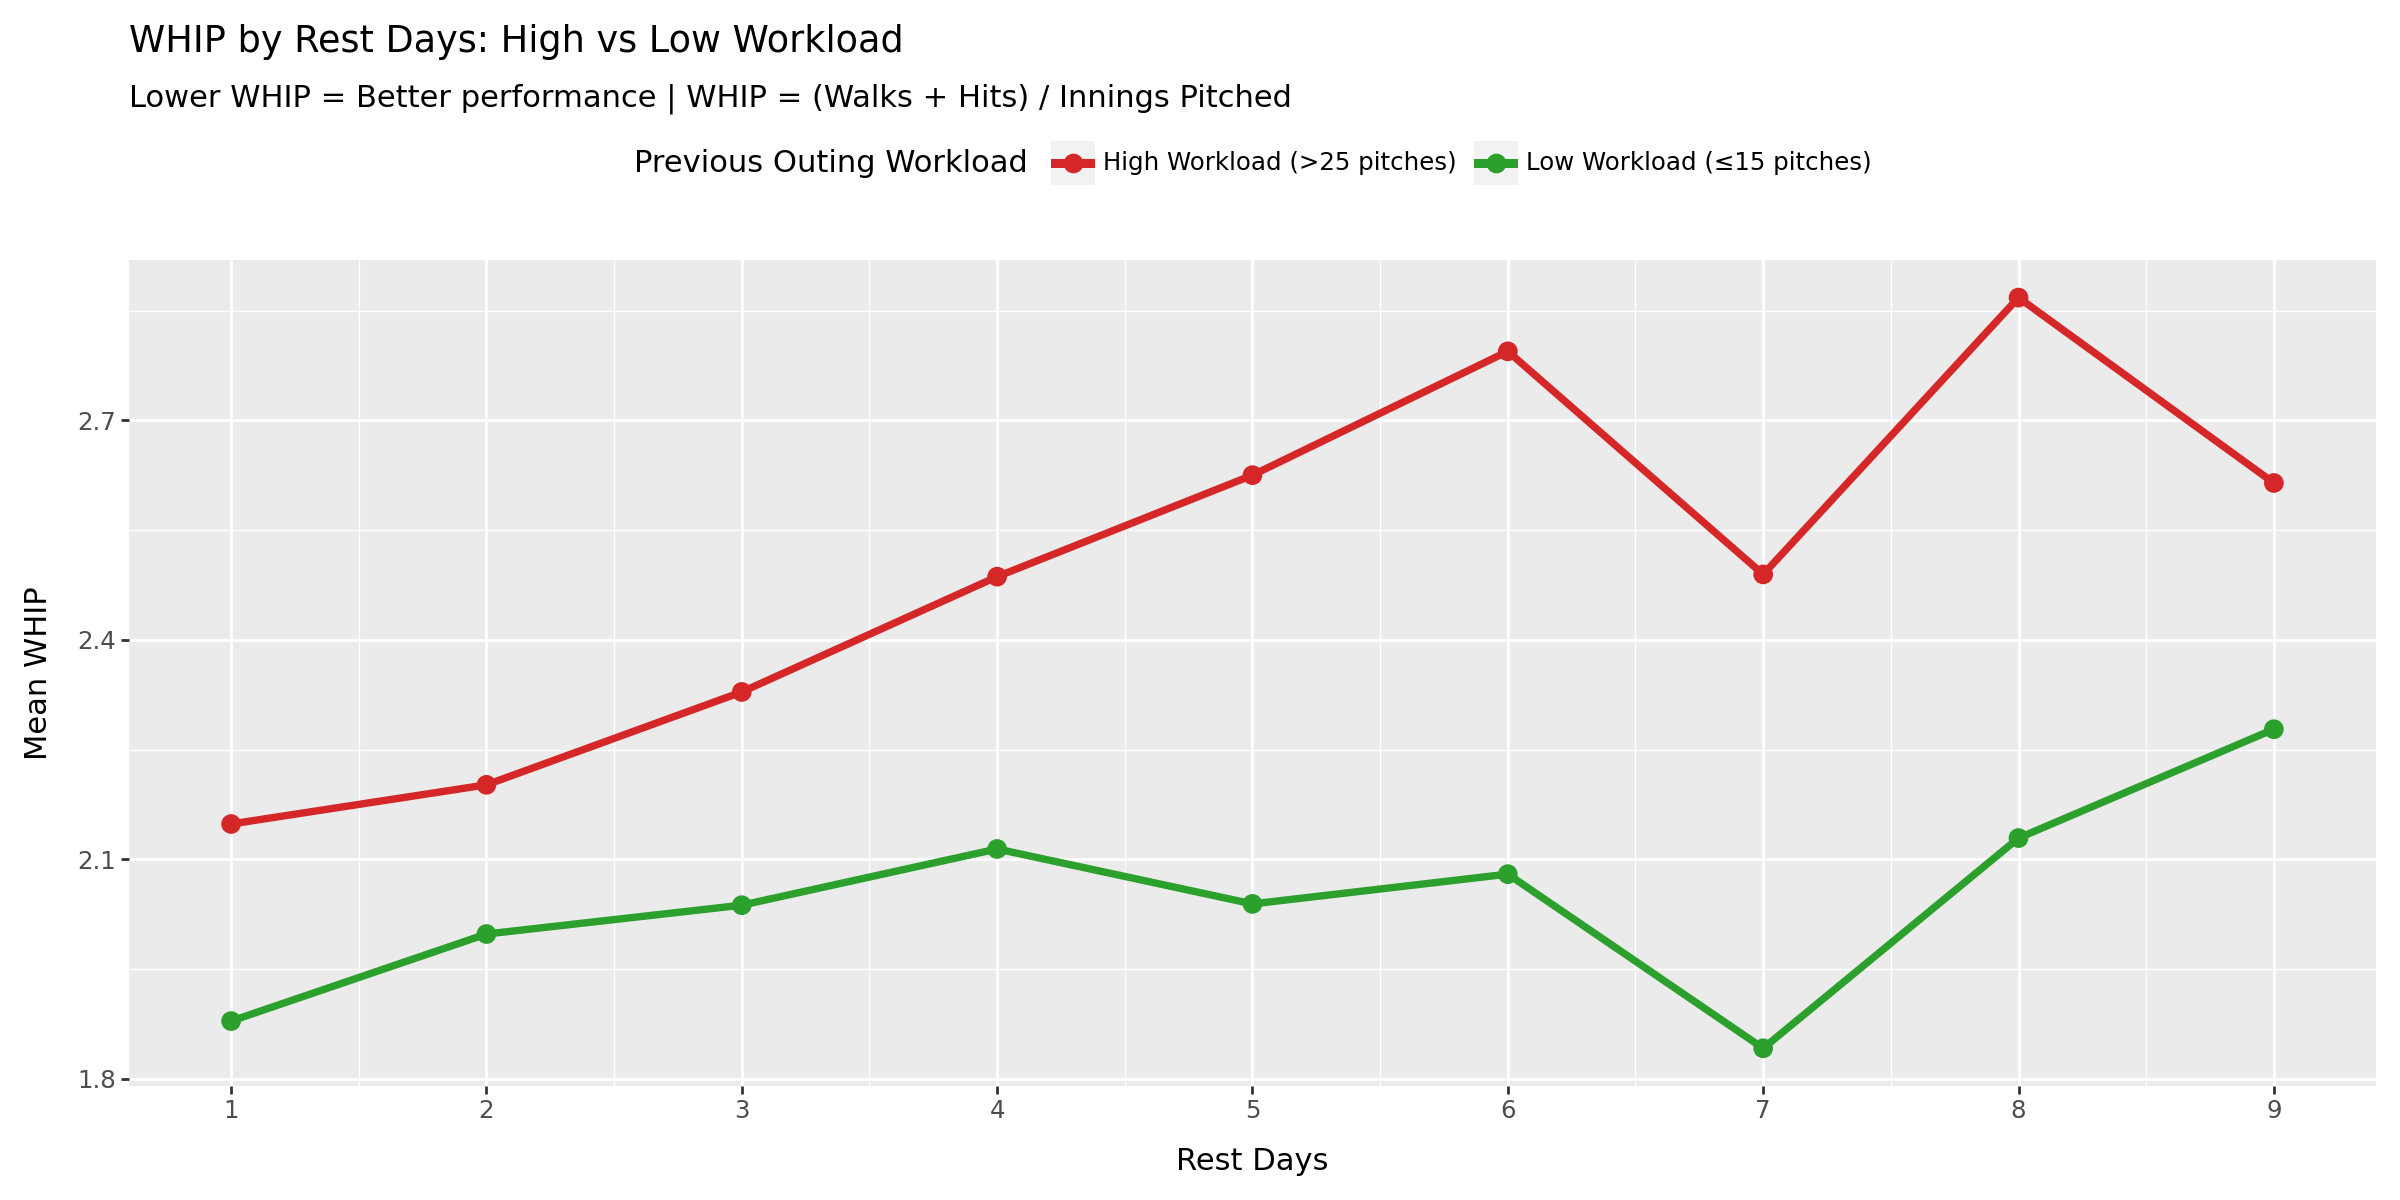

In [191]:
# Line graph: WHIP by rest days - High vs Low workload
(ggplot(whip_by_rest_workload, aes(x='rest_days', y='mean_whip', color='workload_group')) +
 geom_line(size=1.5) +
 geom_point(size=3) +
 labs(title='WHIP by Rest Days: High vs Low Workload',
      subtitle='Lower WHIP = Better performance | WHIP = (Walks + Hits) / Innings Pitched',
      x='Rest Days',
      y='Mean WHIP',
      color='Previous Outing Workload') +
 scale_x_continuous(breaks=range(0, 11)) +
 scale_color_manual(values=['#d62728', '#2ca02c']) +  # Red for high, green for low
 theme(figure_size=(12, 6),
       legend_position='top'))

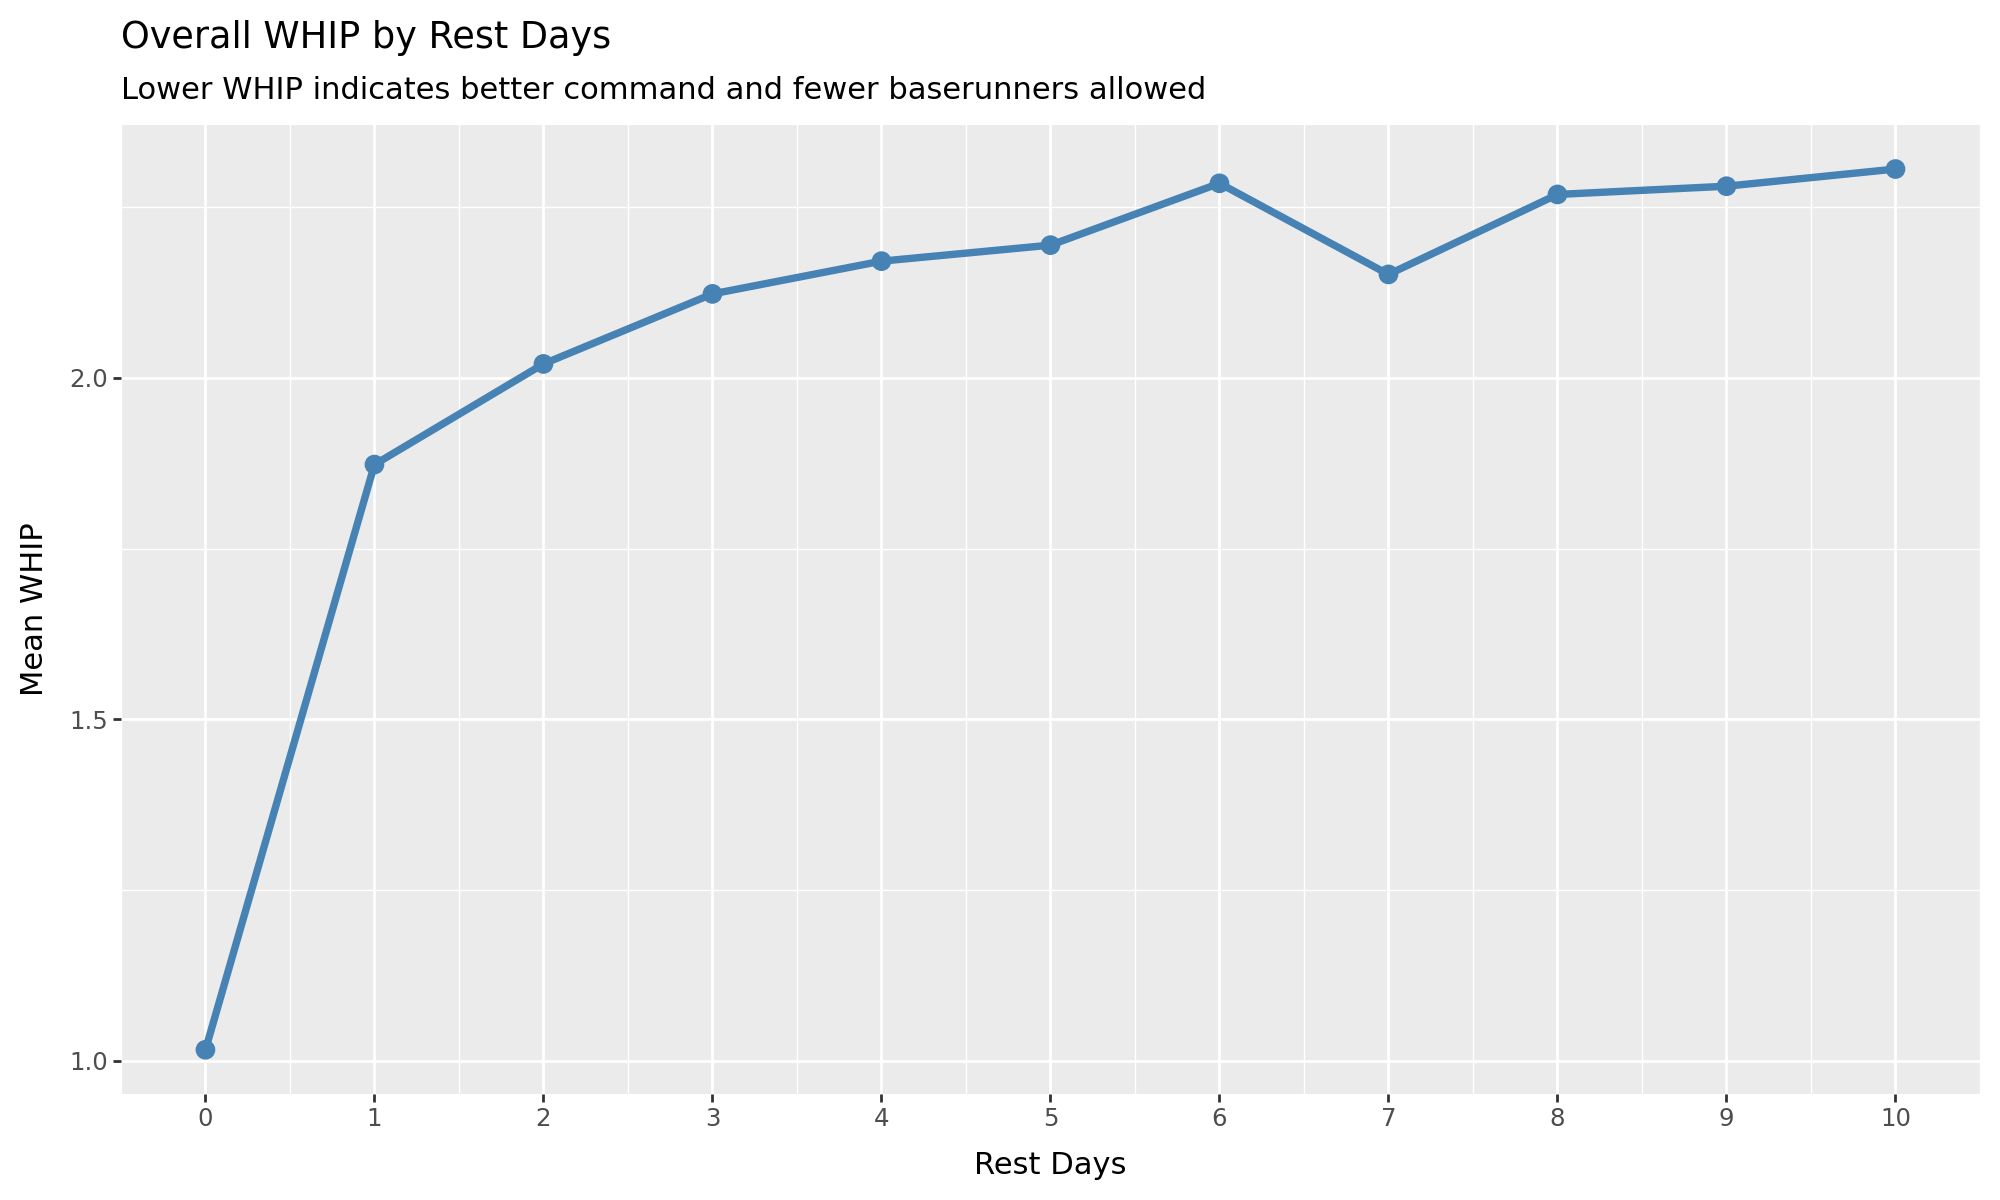

In [192]:
# Overall WHIP by rest days (all pitchers combined)
overall_whip = (whip_with_rest
    .group_by('rest_days')
    .agg([
        pl.col('whip').mean().alias('mean_whip'),
        pl.len().alias('n_outings')
    ])
    .sort('rest_days')
    .to_pandas()
)

(ggplot(overall_whip, aes(x='rest_days', y='mean_whip')) +
 geom_line(color='steelblue', size=1.5) +
 geom_point(color='steelblue', size=3) +
 labs(title='Overall WHIP by Rest Days',
      subtitle='Lower WHIP indicates better command and fewer baserunners allowed',
      x='Rest Days',
      y='Mean WHIP') +
 scale_x_continuous(breaks=range(0, 11)) +
 theme(figure_size=(10, 6)))

In [193]:
# WHIP summary statistics by rest days
whip_summary = (whip_with_rest
    .group_by('rest_days')
    .agg([
        pl.col('whip').mean().alias('mean_whip'),
        pl.col('whip').median().alias('median_whip'),
        pl.len().alias('n_outings'),
        pl.col('walks').mean().alias('avg_walks'),
        pl.col('hits').mean().alias('avg_hits'),
        pl.col('innings_pitched').mean().alias('avg_innings')
    ])
    .sort('rest_days')
)

print("WHIP and components by rest days:")
whip_summary

WHIP and components by rest days:


rest_days,mean_whip,median_whip,n_outings,avg_walks,avg_hits,avg_innings
i64,f64,f64,u32,f64,f64,f64
0,1.016129,1.5,31,0.193548,0.451613,0.655914
1,1.873154,1.5,6705,0.315138,0.759732,0.632712
2,2.020544,1.5,10587,0.351563,0.834325,0.637511
3,2.123088,1.5,8368,0.376793,0.893403,0.641173
4,2.171069,1.5,4694,0.390072,0.906263,0.640747
…,…,…,…,…,…,…
6,2.285058,1.5,1198,0.398998,0.988314,0.643294
7,2.151659,1.5,633,0.382306,0.936809,0.64613
8,2.26875,1.5,320,0.390625,0.99375,0.642708
